In [1]:
import pandas as pd

In [5]:
dfmini = pd.read_csv('./designipadmini7_allcomb.csv')
dfmini['chosen_profile_id'].value_counts()
mini7='iPad_mini_7'

In [6]:
i17e = 'iPhone_17e'
df17e_re16e = pd.read_csv('../iPhone17e_basestorage/output/design17ebasestorage_allcomb_re16e.csv')
df17e_re1616e17 = pd.read_csv('../iPhone17e_basestorage/output/design17ebasestorage_allcomb_re1616e17.csv')

In [10]:
nvidia = 'nvidia_rtx_5090'
dfnvdia = pd.read_csv('../Nvidia/GPT-5-nano_nvidia_design101_allcomb.csv')
dfnvdia['chosen_profile_id'].value_counts()

chosen_profile_id
6129    92
2134    90
2235    83
3640    81
5753    81
        ..
7956    18
281     14
791     10
384     10
7181     7
Name: count, Length: 101, dtype: int64

In [13]:
ps5p = 'PS5Pro'
dfps5pro = pd.read_csv('../PS5Pro/designps5pro_allcomb.csv')
dfps5pro['chosen_profile_id'].value_counts()

chosen_profile_id
PS5Pro    98
PS56      96
PS68      95
PS61      94
PS60      93
          ..
PS32      12
PS2       11
PS4        9
PS1        9
PS77       2
Name: count, Length: 101, dtype: int64

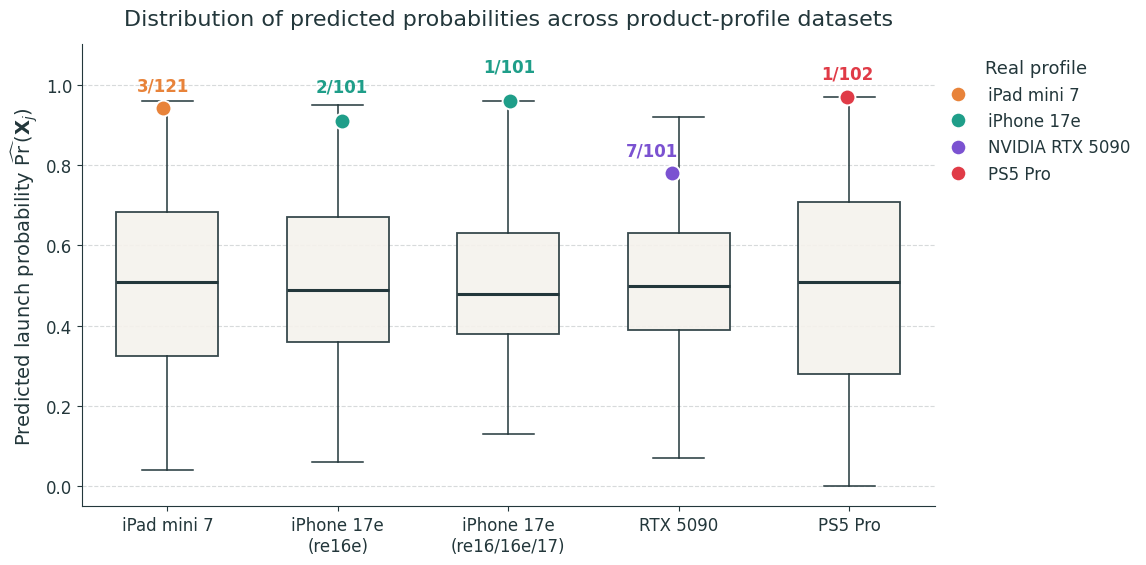

,df_label,real_profile,real_label,prob,rank,total_profiles,rank_label
0,iPad mini 7,iPad_mini_7,iPad mini 7,0.941667,3,121,3/121
1,iPhone 17e\n(re16e),iPhone_17e,iPhone 17e,0.910000,2,101,2/101
2,iPhone 17e\n(re16/16e/17),iPhone_17e,iPhone 17e,0.960000,1,101,1/101
3,RTX 5090,nvidia_rtx_5090,NVIDIA RTX 5090,0.780000,7,101,7/101
4,PS5 Pro,PS5Pro,PS5 Pro,0.970297,1,102,1/102


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Presentation theme colors
MY_PRIMARY = "#23373B"      # dark green-gray
BOX_FILL = "#F5F2ED"        # very light neutral fill
MY_GRID = MY_PRIMARY

plot_specs = [
    ("iPad mini 7", dfmini, mini7, "iPad mini 7"),
    ("iPhone 17e\n(re16e)", df17e_re16e, i17e, "iPhone 17e"),
    ("iPhone 17e\n(re16/16e/17)", df17e_re1616e17, i17e, "iPhone 17e"),
    ("RTX 5090", dfnvdia, nvidia, "NVIDIA RTX 5090"),
    ("PS5 Pro", dfps5pro, ps5p, "PS5 Pro"),
]

profile_colors = {
    "iPad mini 7": "#E8833A",      # vivid orange
    "iPhone 17e": "#1F9E89",       # vivid teal
    "NVIDIA RTX 5090": "#7B52D1",  # vivid purple
    "PS5 Pro": "#E03B47",          # vivid red
}

def predicted_probabilities(df):
    profiles = pd.Index(
        sorted(
            set(df["chosen_profile_id"].dropna()).union(df["nonchosen_profile_id"].dropna()),
            key=str,
        )
    )
    wins = df["chosen_profile_id"].value_counts().reindex(profiles, fill_value=0)
    appearances = (
        df["chosen_profile_id"].value_counts().reindex(profiles, fill_value=0)
        + df["nonchosen_profile_id"].value_counts().reindex(profiles, fill_value=0)
    )
    return wins / appearances

prob_by_df = {}
real_points = []
for label, df, real_profile, real_label in plot_specs:
    probs = predicted_probabilities(df)
    ranks = probs.rank(ascending=False, method="min").astype(int)
    prob_by_df[label] = probs
    real_points.append(
        {
            "df_label": label,
            "real_profile": real_profile,
            "real_label": real_label,
            "prob": probs.loc[real_profile],
            "rank": ranks.loc[real_profile],
            "total_profiles": len(probs),
            "rank_label": f"{ranks.loc[real_profile]}/{len(probs)}",
        }
    )

plot_data = [prob_by_df[label].dropna().values for label, *_ in plot_specs]
xpos = np.arange(1, len(plot_specs) + 1)

np.random.seed(123)
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

bp = ax.boxplot(
    plot_data,
    positions=xpos,
    widths=0.6,
    patch_artist=True,
    showfliers=False,
)
for box in bp["boxes"]:
    box.set(facecolor=BOX_FILL, alpha=0.9, edgecolor=MY_PRIMARY, linewidth=1.3)
for whisker in bp["whiskers"]:
    whisker.set(color=MY_PRIMARY, linewidth=1.1)
for cap in bp["caps"]:
    cap.set(color=MY_PRIMARY, linewidth=1.1)
for median in bp["medians"]:
    median.set(color=MY_PRIMARY, linewidth=2.2)

# Mark the real profile on each dataframe's box plot.
for i, point in enumerate(real_points, start=1):
    x = i + np.random.normal(0, 0.025)
    c = profile_colors[point["real_label"]]
    ax.scatter(
        x,
        point["prob"],
        s=130,
        color=c,
        edgecolor="white",
        linewidth=1.4,
        alpha=1.0,
        zorder=3,
    )
    ax.annotate(
        point["rank_label"],
        (x, point["prob"]),
        xytext=(-15 if point["real_label"] == "NVIDIA RTX 5090" else 0, 18 if point["real_label"] == "iPhone 17e" else 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color=c,
        zorder=4,
    )

legend_handles = [
    Line2D(
        [0], [0],
        marker="o", linestyle="None", markersize=11,
        markerfacecolor=color, markeredgecolor="white", markeredgewidth=1.2,
        label=name,
    )
    for name, color in profile_colors.items()
]
legend = ax.legend(
    handles=legend_handles,
    title="Real profile",
    loc="upper left",
    bbox_to_anchor=(0.99, 1.0),
    frameon=False,
    fontsize=12,
    title_fontsize=13,
)
legend.get_title().set_color(MY_PRIMARY)
for txt in legend.get_texts():
    txt.set_color(MY_PRIMARY)

ax.set_ylabel(
    r"Predicted launch probability $\widehat{\Pr}(\mathbf{X}_j)$",
    fontsize=14, color=MY_PRIMARY,
)
ax.set_xticks(xpos)
ax.set_xticklabels([label for label, *_ in plot_specs], fontsize=13, color=MY_PRIMARY)
ax.set_title(
    "Distribution of predicted probabilities across product-profile datasets",
    fontsize=16, color=MY_PRIMARY, pad=14,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(MY_PRIMARY)
ax.spines["bottom"].set_color(MY_PRIMARY)
ax.tick_params(axis="both", colors=MY_PRIMARY, labelsize=12)
ax.set_ylim(-0.05, 1.1)
ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.18, color=MY_GRID)

plt.savefig(
    "cross_product_predicted_probabilities.png",
    dpi=300, transparent=True, bbox_inches="tight",
)
plt.show()

pd.DataFrame(real_points)
